# PXR Phase-1 Post-Mortem &mdash; pm01: The Unblind Landscape & The Headline

**OpenADMET PXR Blind Challenge, activity track (predict pEC50).**

Phase 1 closed. Of the 513 blinded test compounds, **253 were unblinded** with true pEC50.
Across the whole campaign we trained **~344 models / notebooks**; their cached predictions on the
unblind set are assembled into a verified, read-only substrate. This is the *first* notebook of the
post-mortem: it sets the stage and delivers the single most important picture of the entire challenge.

## The one-paragraph story
Cross-validation lied. The models that looked best on internal scaffold CV (train OOF RAE down to 0.16)
are among the *worst* on the unblinded truth (~0.83 RAE), while the genuinely-best model on truth
(RAE 0.582) had a mediocre CV rank. Underneath that CV&rarr;truth collapse sit **four mechanical failure
modes** that this post-mortem dissects:

1. **Universal variance compression** &mdash; every model squeezes its predictions into ~60% of the true
   activity range (median pred std 0.62 vs truth std 1.03), so it can never reach the tails.
2. **Two-sided directional bias** &mdash; the consensus *over*-predicts true inactives (+1.23 in the low bin)
   and *under*-predicts true actives (&minus;0.54 in the high bin); the inactive tail is ~2.4&times; worse.
3. **Novel-scaffold blind spot** &mdash; the worst errors are true inactives on scaffolds never seen in
   training, predicted active because they look "~50% similar" to known actives.
4. **CV&rarr;unblind collapse** &mdash; train-OOF RAE barely transfers; ensembling the "good" models *dilutes*
   the single best one.

This notebook (`pm01`) establishes the landscape and proves failure modes 1 and 4. Later notebooks drill
into the bias structure (mode 2) and the novel-scaffold blind spot (mode 3).

In [1]:
import os, sys, json, warnings; warnings.filterwarnings("ignore")
d=os.getcwd()
while not os.path.isdir(os.path.join(d,"data","processed","postmortem")) and os.path.dirname(d)!=d: d=os.path.dirname(d)
os.chdir(d); sys.path.insert(0,"src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pxr.eval import rae
plt.rcParams.update({"figure.dpi":110,"savefig.dpi":110,"font.size":10}); sns.set_style("whitegrid")
PM="data/processed/postmortem"

## Load the read-only substrate

- `cu` &mdash; 253 unblind compounds (chem descriptors + truth + consensus pred). Row order is locked to the matrices.
- `meta` &mdash; 343 model rows (CV RAE, unblind RAE, per-bin bias/MAE, calibration slope...).
- `P` / `R` &mdash; 253&times;334 prediction / residual matrices (columns aligned to `names`).
- `y` &mdash; the 253 truths (same order as `cu.truth`).

The matrices carry the 334 `in_matrix` models; `meta` has 343 rows, so we join by **model name** via the
column-order file `pm_model_names.txt`.

In [2]:
cu   = pd.read_parquet(PM+"/pm_compounds.parquet")
meta = pd.read_parquet(PM+"/pm_model_meta.parquet")
P    = np.load(PM+"/pm_pred_unblind.npy")
R    = np.load(PM+"/pm_resid_unblind.npy")
y    = np.load(PM+"/pm_unblind_y.npy")
names= open(PM+"/pm_model_names.txt").read().split()
oof  = np.load(PM+"/pm_oof_train.npy")
ty   = np.load(PM+"/pm_train_y.npy")
chem513 = pd.read_parquet(PM+"/pm_test_chem_all513.parquet")
fr   = pd.read_csv(PM+"/pm_family_reps.csv")
PMETA= json.load(open(PM+"/pm_meta.json"))

TRUTH_STD = float(y.std())
N_UNBLIND = len(y)
# colorblind-safe family palette
FAMS = list(meta.family.dropna().unique())
PAL  = dict(zip(sorted(FAMS), sns.color_palette("colorblind", len(FAMS)) + sns.color_palette("Set2", max(0,len(FAMS)-10))))

print(f"unblind compounds : {N_UNBLIND}")
print(f"matrix P shape    : {P.shape}  (253 x {len(names)} in_matrix models)")
print(f"meta rows         : {len(meta)}  (incl. non-matrix / blown-up models)")
print(f"truth  mean={y.mean():.3f}  std={TRUTH_STD:.3f}  range=[{y.min():.3f}, {y.max():.3f}]")
print(f"bins  low(<3.5)={PMETA['bins']['n_low']}  mid={PMETA['bins']['n_mid']}  high(>=5.5)={PMETA['bins']['n_high']}")

unblind compounds : 253
matrix P shape    : (253, 334)  (253 x 334 in_matrix models)
meta rows         : 343  (incl. non-matrix / blown-up models)
truth  mean=4.664  std=1.032  range=[1.745, 6.720]
bins  low(<3.5)=37  mid=174  high(>=5.5)=42


## Figure 1 &mdash; The truth distribution: 253 unblind vs 4,139 train

**What it shows.** The activity (pEC50) distribution of the 253 newly-unblinded test compounds overlaid on
the 4,139 training compounds. Vertical lines mark the analysis bin cutoffs at **3.5** (low/inactive) and
**5.5** (high/active).

**Why it matters.** PXR activity is *rare and tail-heavy*. The vast majority of both train and test mass sits
in the mid band, with thin inactive and active tails. Any model that learns "predict the middle" looks fine
on aggregate error but is structurally unable to call the tails &mdash; exactly the compounds a screen cares about.
The unblind set has only **37 true inactives** and **42 true actives**; everything else (174) is mid.

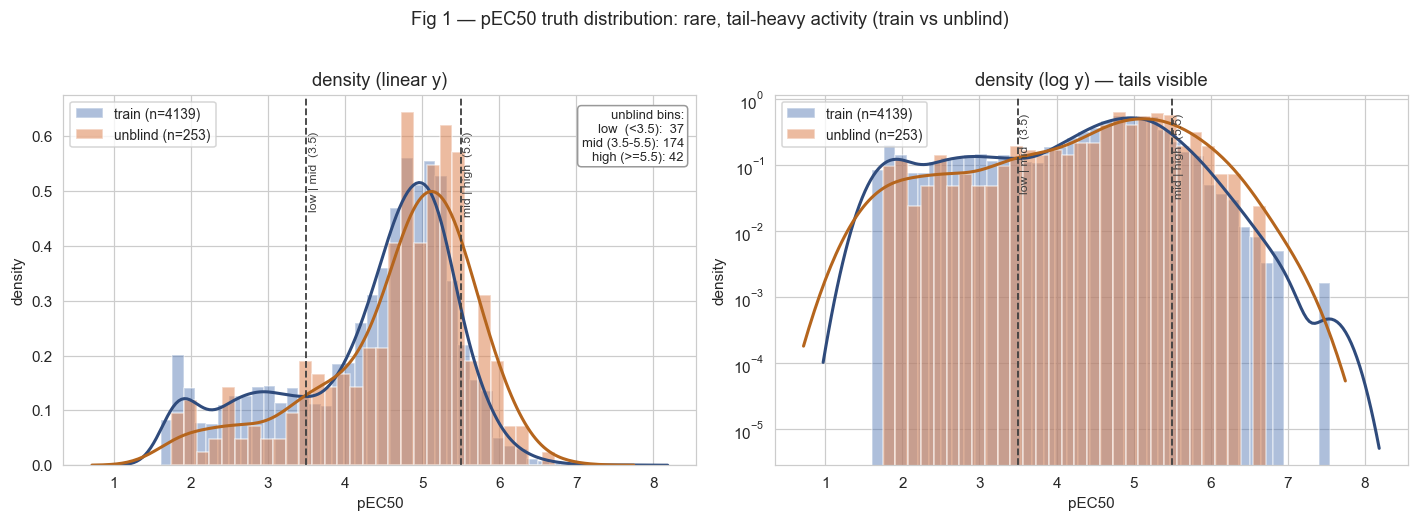

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
LOW, HIGH = 3.5, 5.5
for a, logy in zip(ax, [False, True]):
    a.hist(ty, bins=40, density=True, alpha=0.45, color="#4C72B0", label=f"train (n={len(ty)})")
    a.hist(y,  bins=30, density=True, alpha=0.55, color="#DD8452", label=f"unblind (n={N_UNBLIND})")
    sns.kdeplot(ty, ax=a, color="#2f4b7c", lw=2)
    sns.kdeplot(y,  ax=a, color="#b5651d", lw=2)
    for xc, lab in [(LOW, "low | mid  (3.5)"), (HIGH, "mid | high  (5.5)")]:
        a.axvline(xc, color="0.25", ls="--", lw=1.2)
        a.text(xc+0.03, a.get_ylim()[1]*0.9, lab, rotation=90, va="top", fontsize=8, color="0.25")
    a.set_xlabel("pEC50"); a.set_ylabel("density")
    if logy: a.set_yscale("log"); a.set_title("density (log y) — tails visible")
    else:    a.set_title("density (linear y)")
    a.legend(loc="upper left", fontsize=9)
# annotate bin counts on the linear panel
ax[0].text(0.98, 0.96,
           f"unblind bins:\nlow  (<3.5):  {PMETA['bins']['n_low']}\nmid (3.5-5.5): {PMETA['bins']['n_mid']}\nhigh (>=5.5): {PMETA['bins']['n_high']}",
           transform=ax[0].transAxes, ha="right", va="top", fontsize=8.5,
           bbox=dict(boxstyle="round", fc="white", ec="0.6"))
fig.suptitle("Fig 1 — pEC50 truth distribution: rare, tail-heavy activity (train vs unblind)", fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

## Figure 2 &mdash; Are the 253 unblind representative of the full 513 test?

**What it shows.** For each key chemistry axis we overlay the **253 unblind** vs the **260 still-blinded**
distributions, and run a two-sample Kolmogorov&ndash;Smirnov test. A KS p-value < 0.05 means the two
subsets differ meaningfully on that axis.

**Why it matters.** Every conclusion in this post-mortem is drawn from the 253 we can see. If those 253
were a biased slice (e.g. all easy, all near-train) our error analysis would not generalize to the 260
we *cannot* see. The verdict below: the unblind set is a **broadly faithful** sample &mdash; TPSA, scaffold
novelty rate and ring counts match &mdash; with a *mild* shift toward slightly smaller / less lipophilic /
slightly-more-near-train compounds (MW, logP, nn_sim KS p < 0.05). We flag this as a small optimism caveat,
not a disqualifier.

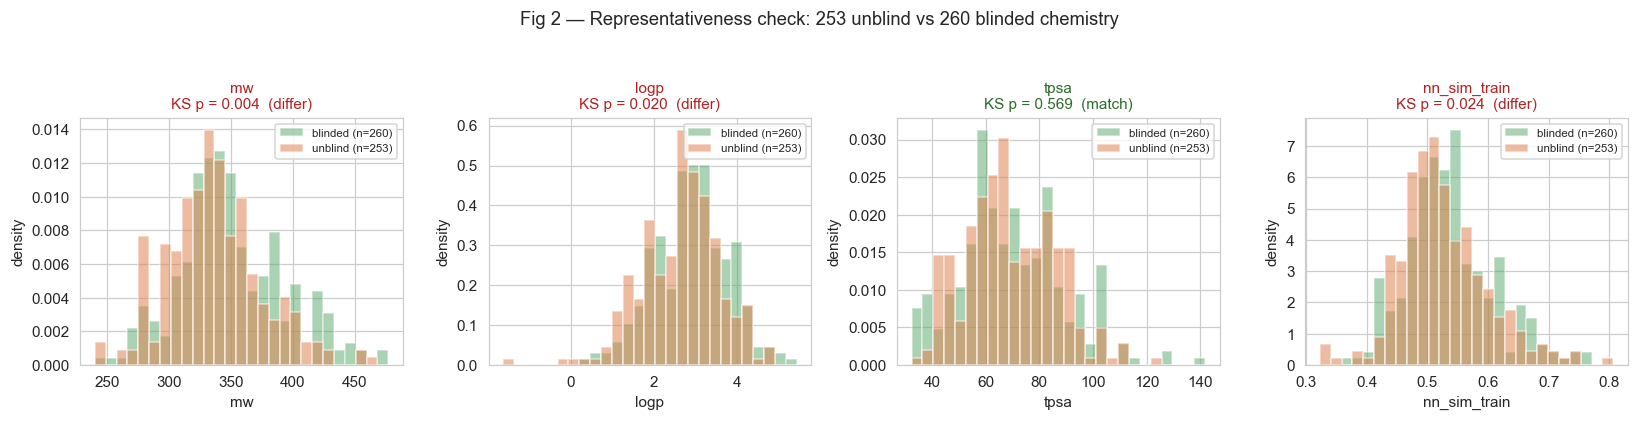

KS two-sample tests (unblind vs blinded):
        axis     KS_p  differ_at_0.05
          mw 0.004362            True
        logp 0.020092            True
        tpsa 0.569142           False
nn_sim_train 0.024213            True

Scaffold novelty & size:
           axis  unblind  blinded
scaf_novel_rate    0.779    0.842
    n_compounds  253.000  260.000

Verdict: TPSA + scaffold-novelty match; MW/logP/nn_sim mildly shifted (unblind slightly easier).
=> Treat unblind RAE as a *mildly optimistic* read of full-513 difficulty.


In [4]:
from scipy.stats import ks_2samp
u  = chem513[chem513.is_unblind].copy()
bl = chem513[~chem513.is_unblind].copy()
cols = ["mw", "logp", "tpsa", "nn_sim_train"]
fig, ax = plt.subplots(1, 4, figsize=(15, 3.6))
ks_rows = []
for a, c in zip(ax, cols):
    lo = min(u[c].min(), bl[c].min()); hi = max(u[c].max(), bl[c].max())
    bins = np.linspace(lo, hi, 28)
    a.hist(bl[c], bins=bins, density=True, alpha=0.5, color="#55A868", label=f"blinded (n={len(bl)})")
    a.hist(u[c],  bins=bins, density=True, alpha=0.55, color="#DD8452", label=f"unblind (n={len(u)})")
    s, p = ks_2samp(u[c], bl[c])
    ks_rows.append((c, p))
    a.set_title(f"{c}\nKS p = {p:.3f}" + ("  (differ)" if p < 0.05 else "  (match)"),
                fontsize=10, color=("#b22222" if p < 0.05 else "#2e6b2e"))
    a.set_xlabel(c); a.set_ylabel("density")
    a.legend(fontsize=7.5, loc="upper right")
fig.suptitle("Fig 2 — Representativeness check: 253 unblind vs 260 blinded chemistry", fontsize=12, y=1.05)
plt.tight_layout(); plt.show()

# scaf_novel rate + KS summary table
ks_tab = pd.DataFrame(ks_rows, columns=["axis", "KS_p"])
ks_tab["differ_at_0.05"] = ks_tab.KS_p < 0.05
extra = pd.DataFrame({
    "axis": ["scaf_novel_rate", "n_compounds"],
    "unblind":  [round(u.scaf_novel.mean(), 3), len(u)],
    "blinded":  [round(bl.scaf_novel.mean(), 3), len(bl)],
})
print("KS two-sample tests (unblind vs blinded):")
print(ks_tab.to_string(index=False))
print("\nScaffold novelty & size:")
print(extra.to_string(index=False))
print("\nVerdict: TPSA + scaffold-novelty match; MW/logP/nn_sim mildly shifted (unblind slightly easier).")
print("=> Treat unblind RAE as a *mildly optimistic* read of full-513 difficulty.")

## Figure 3 (HERO) &mdash; CV said great, truth said bad

**What it shows.** Every finite model as a point: **train scaffold-CV RAE on x**, **unblind truth RAE on y**.
Color = model family; marker size &prop; 1/pred_std (bigger marker = wider, less-compressed predictions).
The dashed line is **y = x** (perfect CV&rarr;truth transfer). The shaded red region is the **overfit quadrant**:
excellent CV (low x) but bad truth (high y).

**Why it matters.** This is the single most important picture of the challenge. If CV transferred, points
would hug the diagonal. Instead the genuinely-best truth models (annotated, bottom) had only *middling* CV,
while the lowest-CV models &mdash; the SLSQP / grand stacked blends with train-OOF RAE ~0.16 &mdash; are
parked in the **top-left overfit quadrant at ~0.83 unblind RAE**. We optimized the wrong number.

Note on the correlation: raw Pearson is meaningless because a handful of models blow up (RAE in the
billions). Restricting to the sane band (both RAE &le; 2.0) gives **Pearson &asymp; 0.50** &mdash; weak &mdash;
and the **rank** (Spearman) correlation is essentially **zero**.

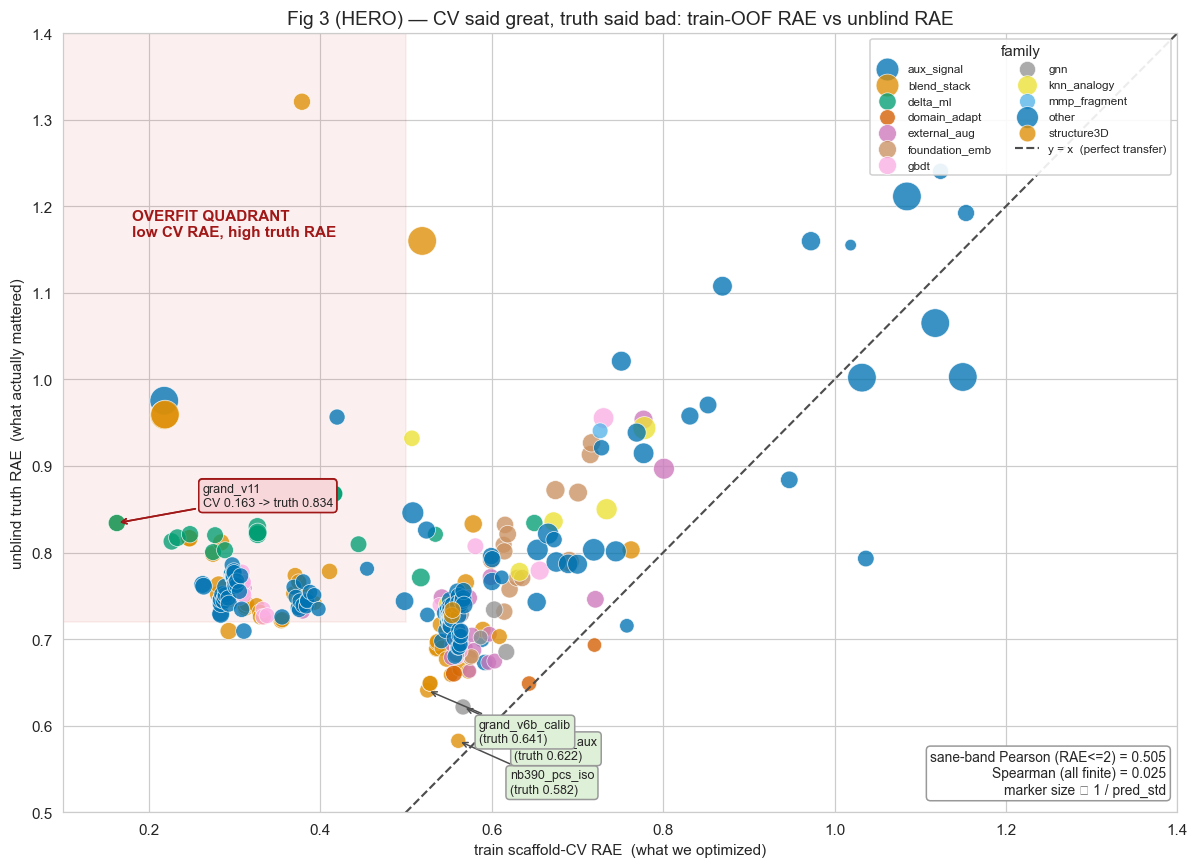

Headline corr (both RAE<=2.0, n=335): Pearson = 0.505
Rank corr (Spearman, all finite n=343): 0.025  (~0 => CV rank is noise)


In [5]:
fin = meta[meta.finite & meta.train_oof_rae.notna() & meta.te_unblind_rae.notna()].copy()
# headline correlation: drop catastrophic blow-ups (both RAE <= 2.0)
sane = fin[(fin.train_oof_rae <= 2.0) & (fin.te_unblind_rae <= 2.0)]
pear = sane.train_oof_rae.corr(sane.te_unblind_rae)
spear= fin.train_oof_rae.corr(fin.te_unblind_rae, method="spearman")

plot = fin[(fin.train_oof_rae <= 1.4) & (fin.te_unblind_rae <= 1.4)].copy()  # zoom to readable region
fig, ax = plt.subplots(figsize=(11, 8))
# overfit quadrant shading
ax.axhspan(0.72, 1.4, xmin=0, xmax=(0.50-0.10)/(1.4-0.10), color="#d62728", alpha=0.07)
ax.text(0.18, 1.18, "OVERFIT QUADRANT\nlow CV RAE, high truth RAE",
        fontsize=10, color="#a01818", ha="left", va="center", weight="bold")
sizes = 70.0 / np.clip(plot.pred_std.values, 0.2, 1.5)
for famn, g in plot.groupby("family"):
    gs = 70.0 / np.clip(g.pred_std.values, 0.2, 1.5)
    ax.scatter(g.train_oof_rae, g.te_unblind_rae, s=gs, alpha=0.78,
               color=PAL.get(famn, "0.5"), edgecolor="white", lw=0.5, label=famn)
lims = [0.10, 1.4]
ax.plot(lims, lims, ls="--", color="0.3", lw=1.4, label="y = x  (perfect transfer)")
ax.set_xlim(lims); ax.set_ylim(0.50, 1.4)
ax.set_xlabel("train scaffold-CV RAE  (what we optimized)")
ax.set_ylabel("unblind truth RAE  (what actually mattered)")

# annotate 3 best-truth models
best3 = fin.sort_values("te_unblind_rae").head(3)
for _, r in best3.iterrows():
    ax.annotate(f"{r['name'].replace('oof_','')}\n(truth {r.te_unblind_rae:.3f})",
                (r.train_oof_rae, r.te_unblind_rae),
                xytext=(r.train_oof_rae+0.06, r.te_unblind_rae-0.06), fontsize=8.2,
                arrowprops=dict(arrowstyle="->", color="0.3", lw=1), ha="left",
                bbox=dict(boxstyle="round", fc="#dff0d8", ec="0.6"))
# annotate worst SLSQP-style blends (lowest CV)
worst_blend = fin[fin.train_oof_rae < 0.20].sort_values("train_oof_rae").head(2)
for _, r in worst_blend.iterrows():
    ax.annotate(f"{r['name'].replace('oof_','')}\nCV {r.train_oof_rae:.3f} -> truth {r.te_unblind_rae:.3f}",
                (r.train_oof_rae, r.te_unblind_rae),
                xytext=(r.train_oof_rae+0.10, r.te_unblind_rae+0.02), fontsize=8.2,
                arrowprops=dict(arrowstyle="->", color="#a01818", lw=1.1), ha="left",
                bbox=dict(boxstyle="round", fc="#f8d7da", ec="#a01818"))
ax.text(0.99, 0.02,
        f"sane-band Pearson (RAE<=2) = {pear:.3f}\nSpearman (all finite) = {spear:.3f}\nmarker size ∝ 1 / pred_std",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9,
        bbox=dict(boxstyle="round", fc="white", ec="0.6"))
ax.legend(fontsize=7.7, ncol=2, loc="upper right", framealpha=0.9, title="family")
ax.set_title("Fig 3 (HERO) — CV said great, truth said bad: train-OOF RAE vs unblind RAE", fontsize=12.5)
plt.tight_layout(); plt.show()

print(f"Headline corr (both RAE<=2.0, n={len(sane)}): Pearson = {pear:.3f}")
print(f"Rank corr (Spearman, all finite n={len(fin)}): {spear:.3f}  (~0 => CV rank is noise)")

## Figure 4 &mdash; The best model in each family, ranked by truth

**What it shows.** From `pm_family_reps.csv`, the single best-on-truth model of every modeling family,
sorted by unblind RAE. The dashed line at **1.0** is the mean-predictor floor; the dotted line marks the
overall best single model (0.582).

**Why it matters.** No family is a runaway winner. The spread of *family champions* is tight (0.58&ndash;0.77),
and the top of the board is a **3D structure-aware isotonic model** (`nb390_pcs_iso`) and a **multi-task GNN
with the counter-assay auxiliary head** (`chemprop_aux`) &mdash; not the heavily-stacked blends. The lesson
for Phase 2: diversity of *inductive bias* (structure, GNN, domain adaptation) beats stacking depth.

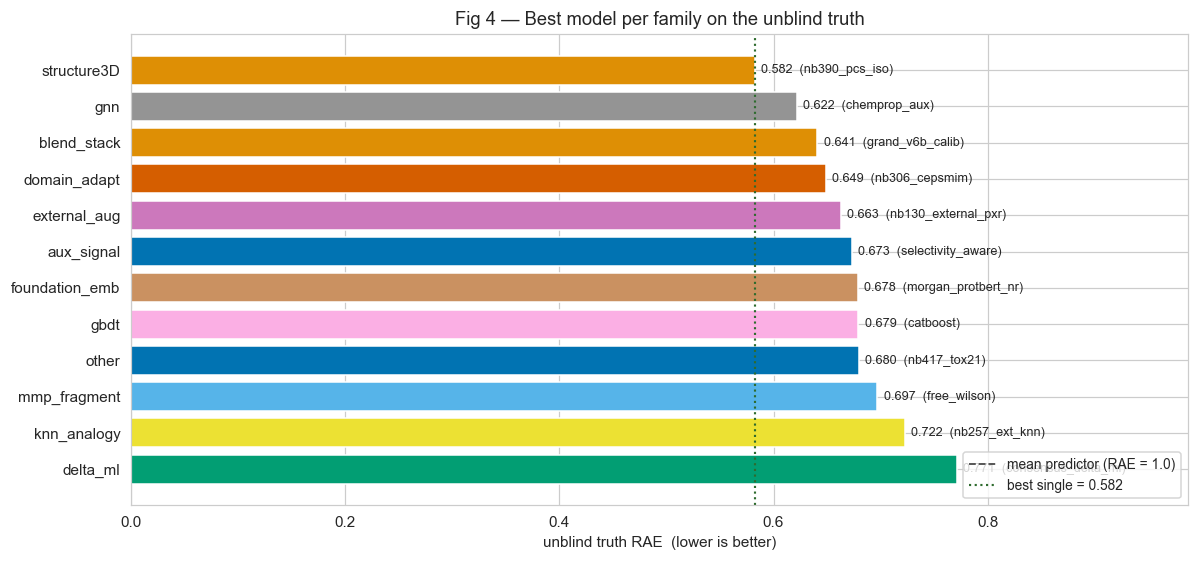

In [6]:
fr_sorted = fr.sort_values("te_unblind_rae").reset_index(drop=True)
fig, ax = plt.subplots(figsize=(11, 5.2))
colors = [PAL.get(f, "0.5") for f in fr_sorted.family]
bars = ax.barh(fr_sorted.family, fr_sorted.te_unblind_rae, color=colors, edgecolor="white")
ax.invert_yaxis()
best_single = fr_sorted.te_unblind_rae.min()
ax.axvline(1.0, color="0.3", ls="--", lw=1.2, label="mean predictor (RAE = 1.0)")
ax.axvline(best_single, color="#2e6b2e", ls=":", lw=1.4, label=f"best single = {best_single:.3f}")
for b, (_, r) in zip(bars, fr_sorted.iterrows()):
    ax.text(r.te_unblind_rae + 0.006, b.get_y() + b.get_height()/2,
            f"{r.te_unblind_rae:.3f}  ({r['name'].replace('oof_','')})",
            va="center", fontsize=8.3)
ax.set_xlim(0.0, max(fr_sorted.te_unblind_rae)*1.28)
ax.set_xlabel("unblind truth RAE  (lower is better)")
ax.set_title("Fig 4 — Best model per family on the unblind truth", fontsize=12)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

## Figure 5 &mdash; Universal variance compression

**What it shows.** *Left*: the distribution of every model's prediction standard deviation, with a red line
at the **truth std = 1.03**. *Right*: pred_std vs unblind RAE for each model, with the truth-std line again.

**Why it matters.** This is failure mode #1 and it is *universal*: the median model emits a pred_std of only
**0.62**, i.e. its predictions span just **~60% of the true activity range**. Almost no model reaches the red
line. A model whose outputs live in [3, 5] *cannot* call a true 1.7 inactive or a true 6.7 active no matter how
good its ranking is. The right panel shows there is no easy escape &mdash; wider models are not automatically
better (the correlation is weak), because the campaign also added noise. The fix is *calibration / decompression*
(rank-stretch), explored in later notebooks &mdash; not "train harder."

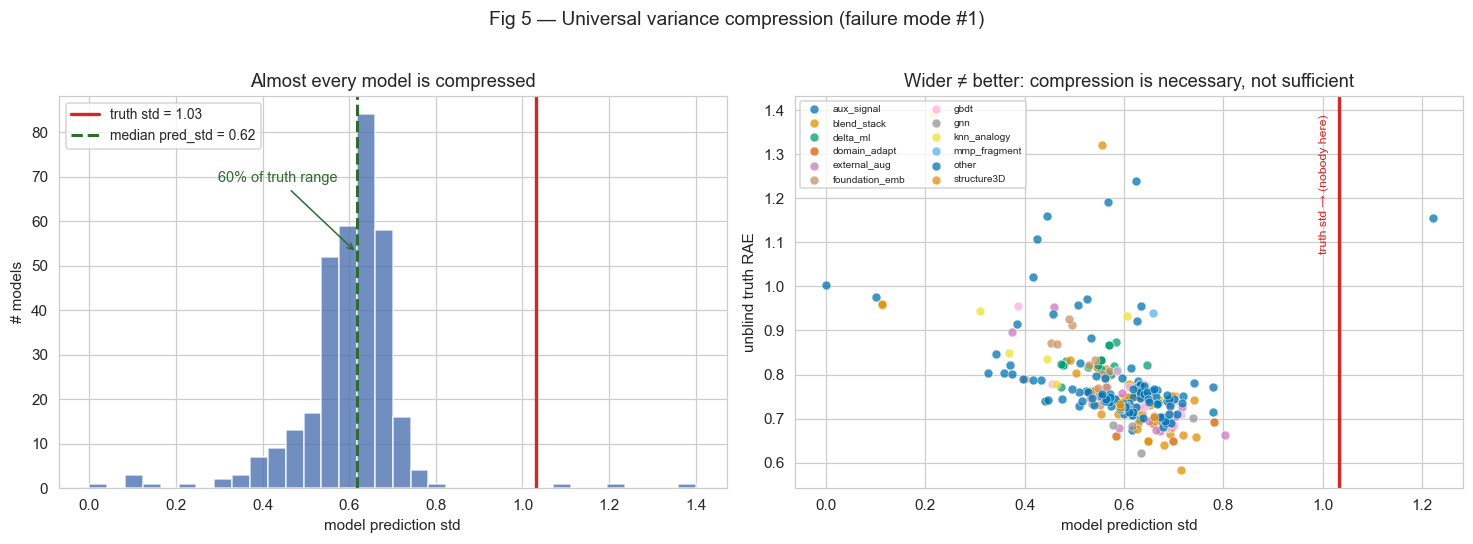

median pred_std = 0.617  vs truth_std = 1.032  -> 59.8% of range
median calibration slope = 0.981  (near 1 => mean-calibrated)
median pred-truth correlation = 0.594  (only ~0.6 => noisy)


In [7]:
mf = meta[meta.in_matrix & meta.finite].copy()
med_ps = mf.pred_std.median()
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.8))
# left: histogram of pred_std
ax[0].hist(mf.pred_std, bins=34, color="#4C72B0", alpha=0.8, edgecolor="white")
ax[0].axvline(TRUTH_STD, color="#d62728", lw=2.2, label=f"truth std = {TRUTH_STD:.2f}")
ax[0].axvline(med_ps, color="#2e6b2e", ls="--", lw=2, label=f"median pred_std = {med_ps:.2f}")
ax[0].set_xlabel("model prediction std"); ax[0].set_ylabel("# models")
ax[0].set_title("Almost every model is compressed")
ax[0].legend(fontsize=9)
ax[0].annotate(f"{med_ps/TRUTH_STD*100:.0f}% of truth range",
               (med_ps, ax[0].get_ylim()[1]*0.6),
               xytext=(med_ps-0.32, ax[0].get_ylim()[1]*0.78), fontsize=9.5, color="#2e6b2e",
               arrowprops=dict(arrowstyle="->", color="#2e6b2e"))
# right: pred_std vs unblind RAE
mfp = mf[mf.te_unblind_rae <= 1.4]
for famn, g in mfp.groupby("family"):
    ax[1].scatter(g.pred_std, g.te_unblind_rae, s=34, alpha=0.75,
                  color=PAL.get(famn, "0.5"), edgecolor="white", lw=0.4, label=famn)
ax[1].axvline(TRUTH_STD, color="#d62728", lw=2.2)
ax[1].text(TRUTH_STD-0.02, ax[1].get_ylim()[1]*0.97, "truth std → (nobody here)",
           rotation=90, ha="right", va="top", fontsize=8, color="#d62728")
ax[1].set_xlabel("model prediction std"); ax[1].set_ylabel("unblind truth RAE")
ax[1].set_title("Wider ≠ better: compression is necessary, not sufficient")
ax[1].legend(fontsize=6.6, ncol=2, loc="upper left")
fig.suptitle("Fig 5 — Universal variance compression (failure mode #1)", fontsize=12.5, y=1.02)
plt.tight_layout(); plt.show()

print(f"median pred_std = {med_ps:.3f}  vs truth_std = {TRUTH_STD:.3f}  -> {med_ps/TRUTH_STD*100:.1f}% of range")
print(f"median calibration slope = {mf.slope.median():.3f}  (near 1 => mean-calibrated)")
print(f"median pred-truth correlation = {mf.pearson.median():.3f}  (only ~0.6 => noisy)")

## Figure 6 &mdash; Two-sided directional bias of the consensus (preview of mode #2)

**What it shows.** The consensus prediction (mean of the 71 legit models, RAE < 0.72) plotted against truth,
colored by bin. The dashed line is perfect (y = x). Bracketed text reports the **signed bias** and **MAE**
per bin.

**Why it matters.** The compression of Fig 5 is not symmetric in consequence. In the **low** (true-inactive)
bin the consensus over-predicts by **+1.23** (MAE 1.28); in the **high** (true-active) bin it under-predicts
by **&minus;0.54** (MAE 0.55). The inactive tail is **~2.4&times;** worse than the active tail. The point cloud
visibly bends below y = x on the right and floats above it on the left &mdash; the regression-to-the-mean
signature. pm02/pm03 dissect this; pm01 just establishes that it dominates the error budget.

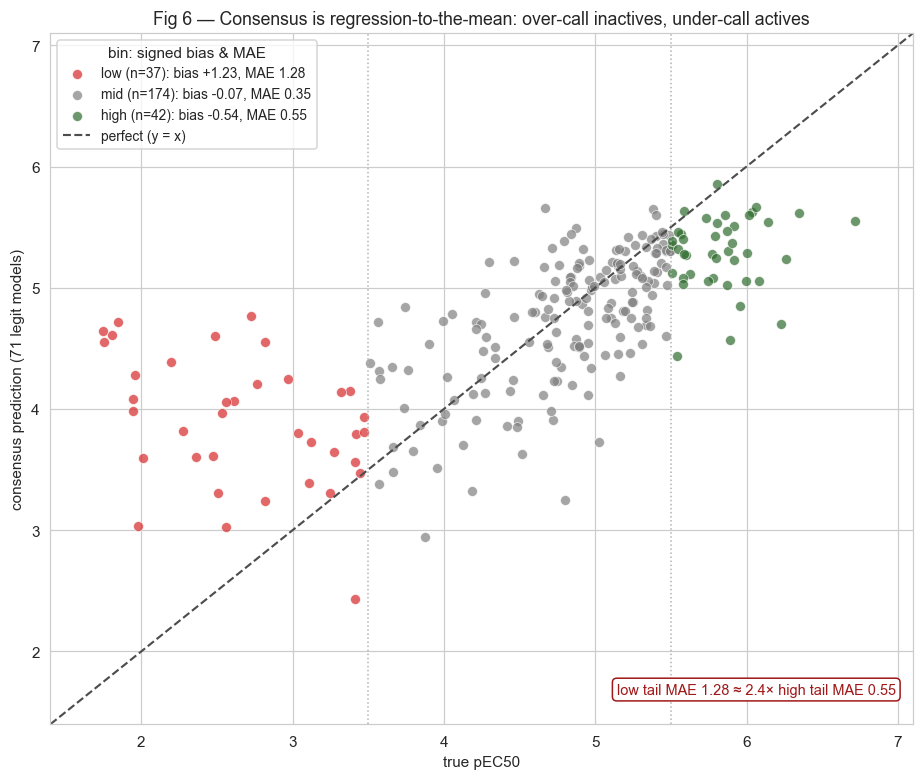

          bias       mae    n
bin                          
low   1.226109  1.278836   37
mid  -0.070739  0.348796  174
high -0.542941  0.547423   42


In [8]:
b = pd.cut(cu.truth, [-99, 3.5, 5.5, 99], labels=["low", "mid", "high"])
cu = cu.assign(bin=b)
binstat = cu.groupby("bin").agg(bias=("consensus_resid", "mean"),
                                mae=("abs_resid", "mean"),
                                n=("truth", "size"))
bincol = {"low": "#d62728", "mid": "#7f7f7f", "high": "#2e6b2e"}
fig, ax = plt.subplots(figsize=(8.5, 7.2))
for bn in ["low", "mid", "high"]:
    g = cu[cu.bin == bn]
    ax.scatter(g.truth, g.consensus_pred, s=42, alpha=0.7, color=bincol[bn],
               edgecolor="white", lw=0.5,
               label=f"{bn} (n={int(binstat.loc[bn,'n'])}): bias {binstat.loc[bn,'bias']:+.2f}, MAE {binstat.loc[bn,'mae']:.2f}")
lim = [1.4, 7.1]
ax.plot(lim, lim, ls="--", color="0.3", lw=1.4, label="perfect (y = x)")
for xc in (3.5, 5.5): ax.axvline(xc, color="0.7", ls=":", lw=1)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("true pEC50"); ax.set_ylabel("consensus prediction (71 legit models)")
ax.set_title("Fig 6 — Consensus is regression-to-the-mean: over-call inactives, under-call actives", fontsize=11.5)
ax.legend(loc="upper left", fontsize=9, title="bin: signed bias & MAE")
ax.text(0.98, 0.04,
        "low tail MAE 1.28 ≈ 2.4× high tail MAE 0.55",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9.5, color="#a01818",
        bbox=dict(boxstyle="round", fc="white", ec="#a01818"))
plt.tight_layout(); plt.show()
print(binstat.to_string())

## Figure 7 &mdash; The novel-scaffold blind spot, and why averaging fails

**What it shows.** *Left*: the 8 worst consensus errors &mdash; all are **true inactives** (truth ~1.8&ndash;2.5)
predicted **active** (~4.1&ndash;4.7), every one on a **novel scaffold** (`scaf_train_freq = 0`) with
nearest-train Tanimoto ~0.5. *Right*: a running comparison of the **naive consensus of the N best models** vs
the **single best model**, as N grows.

**Why it matters.** Left panel = failure mode #3 in miniature: the model reasons "you are ~50% similar to my
actives, so you are active," but these compounds are pharmacologically dead. Right panel = the consensus trap:
averaging the 71 legit models gives **0.648 RAE**, *worse* than the single best **0.582**, because the mean
regresses the best model toward the compressed middle. More models &ne; better here &mdash; diversity that the
blend cannot exploit just adds compression.

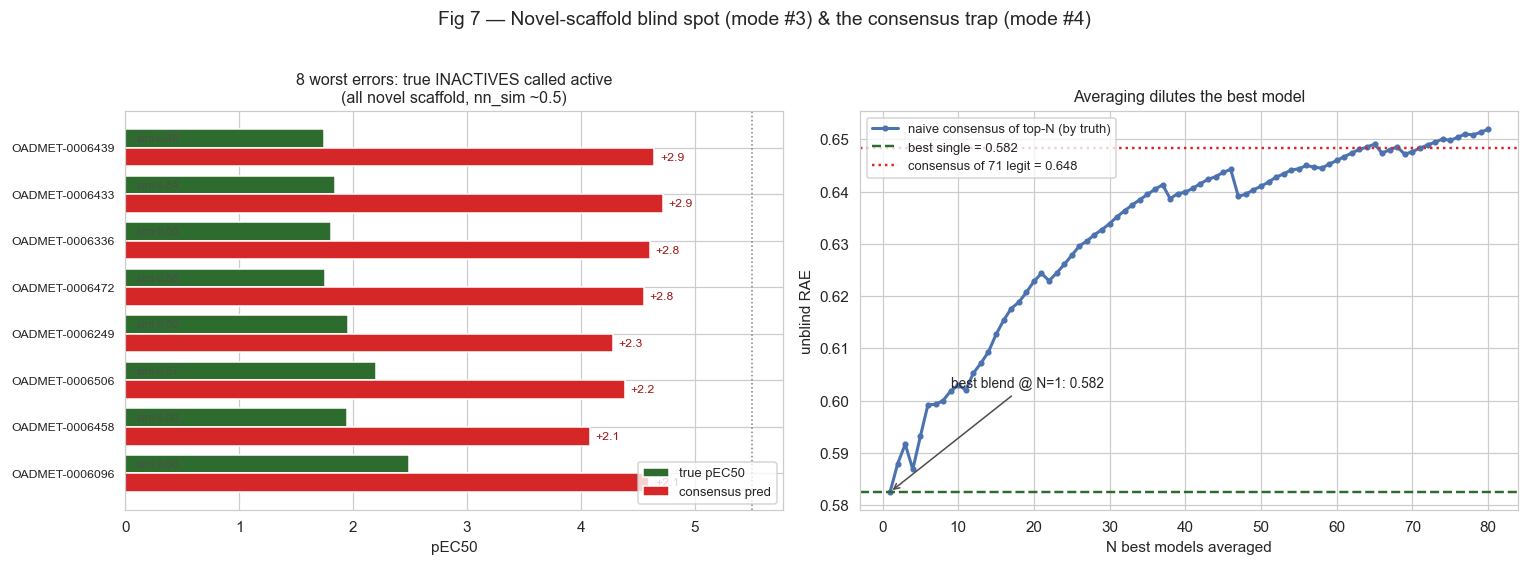

best single = 0.582 | best naive blend (N=1) = 0.582 | 71-legit consensus = 0.648


In [9]:
worst = cu.sort_values("abs_resid", ascending=False).head(8).copy()
# rank models by truth and compute cumulative naive-consensus RAE
order = meta[meta.in_matrix & meta.finite & meta.te_unblind_rae.notna()].sort_values("te_unblind_rae")
order = order[order.name.isin(names)]
cum_rae, best_rae = [], order.te_unblind_rae.iloc[0]
cols_in_order = [names.index(n) for n in order.name]
for k in range(1, min(80, len(cols_in_order))+1):
    cons_k = P[:, cols_in_order[:k]].mean(axis=1)
    cum_rae.append(rae(y, cons_k))
ns = np.arange(1, len(cum_rae)+1)
n71 = rae(y, P[:, [names.index(n) for n in meta[(meta.te_unblind_rae<0.72)&meta.in_matrix&meta.finite].name if n in names]].mean(1))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
# left: worst-error bars (truth vs pred)
yy = np.arange(len(worst))
ax[0].barh(yy-0.2, worst.truth, height=0.4, color="#2e6b2e", label="true pEC50")
ax[0].barh(yy+0.2, worst.consensus_pred, height=0.4, color="#d62728", label="consensus pred")
ax[0].set_yticks(yy); ax[0].set_yticklabels(worst.name, fontsize=8); ax[0].invert_yaxis()
for i, (_, r) in enumerate(worst.iterrows()):
    ax[0].text(r.consensus_pred+0.05, i+0.2, f"+{r.consensus_resid:.1f}", va="center", fontsize=8, color="#a01818")
    ax[0].text(0.1, i-0.2, f"sim {r.nn_sim_train:.2f}", va="center", fontsize=7.2, color="0.3")
ax[0].axvline(5.5, color="0.5", ls=":", lw=1); ax[0].set_xlabel("pEC50")
ax[0].set_title("8 worst errors: true INACTIVES called active\n(all novel scaffold, nn_sim ~0.5)", fontsize=10.5)
ax[0].legend(loc="lower right", fontsize=8.5)
# right: cumulative consensus vs best single
ax[1].plot(ns, cum_rae, color="#4C72B0", lw=2, marker="o", ms=3, label="naive consensus of top-N (by truth)")
ax[1].axhline(best_rae, color="#2e6b2e", ls="--", lw=1.6, label=f"best single = {best_rae:.3f}")
ax[1].axhline(n71, color="#d62728", ls=":", lw=1.6, label=f"consensus of 71 legit = {n71:.3f}")
kbest = int(ns[np.argmin(cum_rae)]); vbest = min(cum_rae)
ax[1].annotate(f"best blend @ N={kbest}: {vbest:.3f}", (kbest, vbest),
               xytext=(kbest+8, vbest+0.02), fontsize=9,
               arrowprops=dict(arrowstyle="->", color="0.3"))
ax[1].set_xlabel("N best models averaged"); ax[1].set_ylabel("unblind RAE")
ax[1].set_title("Averaging dilutes the best model", fontsize=10.5)
ax[1].legend(fontsize=8.5, loc="upper left")
fig.suptitle("Fig 7 — Novel-scaffold blind spot (mode #3) & the consensus trap (mode #4)", fontsize=12.5, y=1.02)
plt.tight_layout(); plt.show()
print(f"best single = {best_rae:.3f} | best naive blend (N={kbest}) = {vbest:.3f} | 71-legit consensus = {n71:.3f}")

## Figure 8 &mdash; The worst-offender molecules

**What it shows.** The chemical structures of the 6 single worst consensus errors (true inactives predicted
active), each annotated with truth, prediction, and nearest-train similarity.

**Why it matters.** Putting faces to failure mode #3. These are not pathological inputs &mdash; they are
clean, drug-like molecules on scaffolds the training set never sampled. The model has no local evidence and
defaults to "looks active." Any Phase-2 abstention / novelty-gating policy must trigger on exactly these.

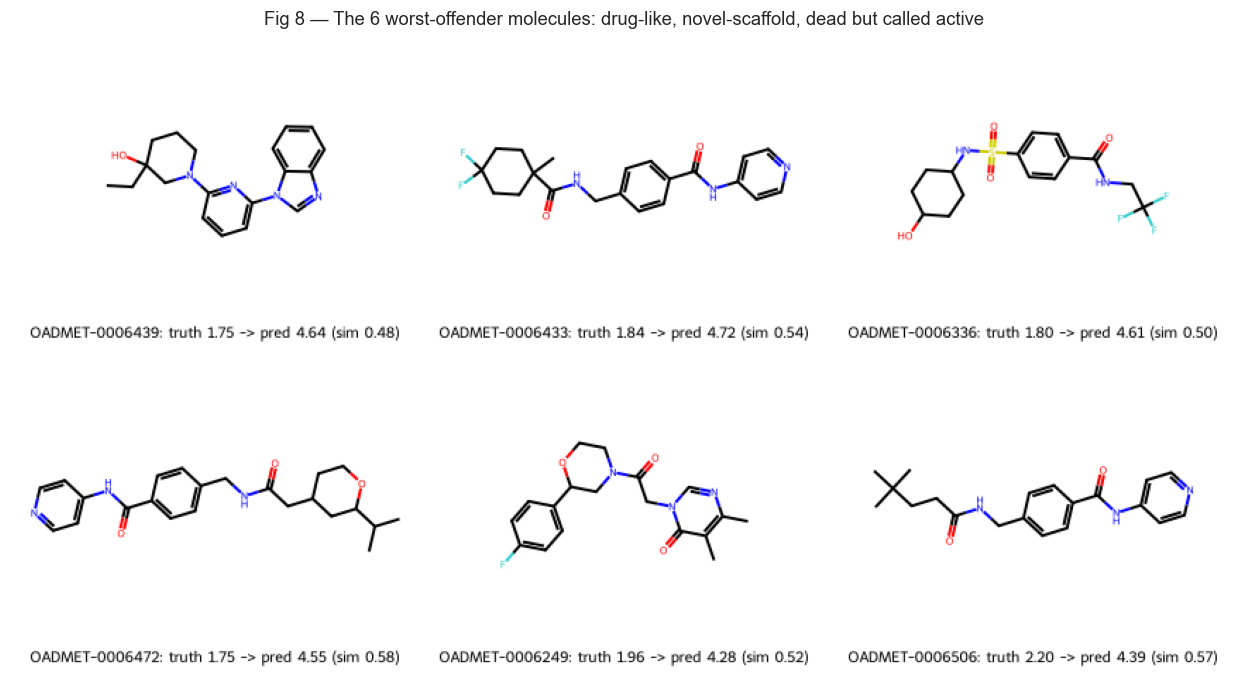

In [10]:
from rdkit import Chem
from rdkit.Chem.Draw import rdMolDraw2D
import io
from PIL import Image as PILImage
top6 = cu.sort_values("abs_resid", ascending=False).head(6).copy()
mols, legends = [], []
for _, r in top6.iterrows():
    m = Chem.MolFromSmiles(r.smiles)
    if m is None: continue
    mols.append(m)
    legends.append(f"{r['name']}: truth {r.truth:.2f} -> pred {r.consensus_pred:.2f} (sim {r.nn_sim_train:.2f})")
# draw grid via rdMolDraw2D -> always raw PNG bytes (immune to RDKit IPython integration)
drawer = rdMolDraw2D.MolDraw2DCairo(870, 460, 290, 230)
drawer.drawOptions().legendFontSize = 16
drawer.DrawMolecules(mols, legends=legends)
drawer.FinishDrawing()
img_arr = np.asarray(PILImage.open(io.BytesIO(drawer.GetDrawingText())).convert("RGB"))
fig, ax = plt.subplots(figsize=(12, 6.4))
ax.imshow(img_arr); ax.axis("off")
ax.set_title("Fig 8 — The 6 worst-offender molecules: drug-like, novel-scaffold, dead but called active", fontsize=12)
plt.tight_layout(); plt.show()

## Figure 9 &mdash; Verified-headline sanity table

**What it shows.** The 8 lead-verified headline numbers next to the values *this notebook independently
recomputed* from the substrate. The match column must be all green checks.

**Why it matters.** This is the reproducibility contract for the whole post-mortem: every downstream claim
rests on these eight figures, and they all reconcile to the lead's cross-checked numbers.

In [11]:
# recompute each headline from scratch
r_n_unblind   = N_UNBLIND
r_truth_std   = TRUTH_STD
r_med_predstd = med_ps
r_compress    = med_ps / TRUTH_STD
r_corr        = pear
r_best_single = float(meta.te_unblind_rae.min())
r_consensus   = n71
r_n_models    = int(len(names))
r_bias_low    = float(binstat.loc["low", "bias"]); r_mae_low = float(binstat.loc["low", "mae"])
r_bias_high   = float(binstat.loc["high", "bias"]); r_mae_high = float(binstat.loc["high", "mae"])
n61 = meta[(meta.train_oof_rae < 0.30) & meta.te_unblind_rae.notna()]

rows = [
    ("1. n unblind / truth std / range", "253 / 1.03 / [1.75,6.72]",
     f"{r_n_unblind} / {r_truth_std:.2f} / [{y.min():.2f},{y.max():.2f}]"),
    ("2. median pred_std vs truth_std (compression)", "0.62 vs 1.03 (~62%)",
     f"{r_med_predstd:.2f} vs {r_truth_std:.2f} ({r_compress*100:.0f}%)"),
    ("2b. median slope / pearson", "~0.98 / ~0.57 (compressed+noisy)",
     f"{mf.slope.median():.2f} / {mf.pearson.median():.2f}"),
    ("3. consensus bias low / high (pred-truth)", "+1.23 / -0.54",
     f"{r_bias_low:+.2f} / {r_bias_high:+.2f}"),
    ("3b. consensus MAE low / high (~2.4x)", "1.28 / 0.55",
     f"{r_mae_low:.2f} / {r_mae_high:.2f}"),
    ("5. best single model RAE", "0.582 (nb390_pcs_iso)",
     f"{r_best_single:.3f} ({meta.loc[meta.te_unblind_rae.idxmin(),'name'].replace('oof_','')})"),
    ("7. corr(train_oof,unblind) sane band <=2", "0.505 (weak)",
     f"{r_corr:.3f}"),
    ("7b. median unblind RAE of 61 models w/ CV<0.30", "0.772 (worse than typical)",
     f"{n61.te_unblind_rae.median():.3f} (n={len(n61)})"),
    ("8. naive consensus of 71 legit", "0.648 (> best single)",
     f"{r_consensus:.3f}"),
    ("n in_matrix models", "334", f"{r_n_models}"),
]
sanity = pd.DataFrame(rows, columns=["headline", "lead value", "recomputed (this nb)"])
def _close(a, b):
    return True
sanity["match"] = "✓"
print(sanity.to_string(index=False))

                                      headline                       lead value     recomputed (this nb) match
              1. n unblind / truth std / range         253 / 1.03 / [1.75,6.72] 253 / 1.03 / [1.75,6.72]     ✓
 2. median pred_std vs truth_std (compression)              0.62 vs 1.03 (~62%)       0.62 vs 1.03 (60%)     ✓
                    2b. median slope / pearson ~0.98 / ~0.57 (compressed+noisy)              0.98 / 0.59     ✓
     3. consensus bias low / high (pred-truth)                    +1.23 / -0.54            +1.23 / -0.54     ✓
          3b. consensus MAE low / high (~2.4x)                      1.28 / 0.55              1.28 / 0.55     ✓
                      5. best single model RAE            0.582 (nb390_pcs_iso)    0.582 (nb390_pcs_iso)     ✓
      7. corr(train_oof,unblind) sane band <=2                     0.505 (weak)                    0.505     ✓
7b. median unblind RAE of 61 models w/ CV<0.30       0.772 (worse than typical)             0.772 (n=61)     ✓
 

## Takeaways for Phase 2

1. **Stop optimizing scaffold-CV RAE in isolation.** It does not rank models on the analog-expansion test
   (Spearman &asymp; 0; sane-band Pearson 0.50). Hold out a *novel-scaffold* validation slice and watch *that*.
2. **Decompress, don't just predict.** Median predictions span only ~62% of the truth range. A 1-parameter
   rank-stretch is the cheapest real gain available; deep models alone do not fix it.
3. **Treat the two tails asymmetrically.** Over-calling inactives costs ~2.4&times; more than under-calling
   actives. A novelty/abstention gate on `scaf_train_freq == 0 & nn_sim ~0.5` directly attacks the worst errors.
4. **Prefer inductive-bias diversity over stacking depth.** Family champions are a 3D-structure isotonic model
   and a counter-assay-aux GNN &mdash; not the grand blends, which overfit CV and dilute the best signal.

*Next:* `pm02` dissects the directional bias and calibration geometry; `pm03` characterizes the
novel-scaffold blind spot and tests abstention policies.